In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

In [23]:
import os
print("Current directory:", os.getcwd())
print("\nIsi current directory:")
print(os.listdir('.'))
print("\nIsi parent directory:")
print(os.listdir('..'))

Current directory: d:\Binus\Semester 4\NLP\Final Project\Notebook\All-Model comparison

Isi current directory:
['Master-Comparison.ipynb', 'metrics_comparison_summary.csv']

Isi parent directory:
['All-Model comparison', 'nlp-bart-model.ipynb', 'nlp-bart-summarization.ipynb', 'nlp-led-summarization.ipynb', 'nlp-longt5-summarization.ipynb', 'nlp-pegasus-summarization.ipynb', 'nlp-textrank-summarization.ipynb']


In [24]:
# ========== 1. LOAD SEMUA CSV ==========
csv_files = {
    'BART': '../../Result/BART/bart_rouge_results.csv',
    'LED': '../../Result/LED/led_rouge_results.csv',
    'LongT5': '../../Result/LongT5/longt5_rouge_results.csv',
    'Pegasus': '../../Result/Pegasus/pegasus_rouge_results.csv',
    'Textrank': '../../Result/Textrank/textrank_rouge_results.csv'
}


all_data = {}
for model_name, csv_path in csv_files.items():
    df = pd.read_csv(csv_path)
    all_data[model_name] = df
    print(f"✓ {model_name} loaded: {len(df)} rows")

✓ BART loaded: 1 rows
✓ LED loaded: 1 rows
✓ LongT5 loaded: 1 rows
✓ Pegasus loaded: 1 rows
✓ Textrank loaded: 1 rows


In [25]:
# ========== DEBUG: CHECK COLUMN NAMES ==========
print("Column names di tiap file:\n")
for model_name, df in all_data.items():
    print(f"{model_name}:")
    print(f"  {df.columns.tolist()}")
    print()

Column names di tiap file:

BART:
  ['Model', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Tipe', 'Dataset', 'Test Samples']

LED:
  ['Model', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Tipe', 'Dataset', 'Max Input Tokens', 'Test Samples']

LongT5:
  ['Model', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Tipe', 'Dataset', 'Max Input Tokens', 'Test Samples']

Pegasus:
  ['Model', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Tipe', 'Dataset', 'Test Samples']

Textrank:
  ['Model', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L']



In [26]:
# ========== 2. AGGREGATE METRICS (ROBUST VERSION) ==========
comparison_data = []

for model_name, df in all_data.items():
    row = {
        'Model': model_name,
        'ROUGE-1': df['ROUGE-1'].mean(),
        'ROUGE-2': df['ROUGE-2'].mean(),
        'ROUGE-L': df['ROUGE-L'].mean(),
        'Tipe': df['Tipe'].iloc[0] if 'Tipe' in df.columns else 'N/A',
        'Dataset': df['Dataset'].iloc[0] if 'Dataset' in df.columns else 'N/A',
        'Max Input Tokens': df['Max Input Tokens'].iloc[0] if 'Max Input Tokens' in df.columns else 'N/A',
        'Test Samples': df['Test Samples'].iloc[0] if 'Test Samples' in df.columns else 'N/A'
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(comparison_df.to_string(index=False))


COMPARISON SUMMARY
   Model  ROUGE-1  ROUGE-2  ROUGE-L                   Tipe                            Dataset Max Input Tokens Test Samples
    BART    42.37    16.48    24.15   Abstractive Baseline                             PubMed              N/A          500
     LED    41.95    16.61    24.42          Long-Document PubMed (ccdv/pubmed-summarization)             8192          500
  LongT5    31.80     9.62    17.52 Long-Document Baseline PubMed (ccdv/pubmed-summarization)             4096          500
 Pegasus    33.54    12.11    20.28   Abstractive Baseline                             PubMed              N/A          500
Textrank    39.31    14.32    21.06                    N/A                                N/A              N/A          N/A


Text(0.5, 1.0, 'ROUGE Scores Comparison Heatmap')

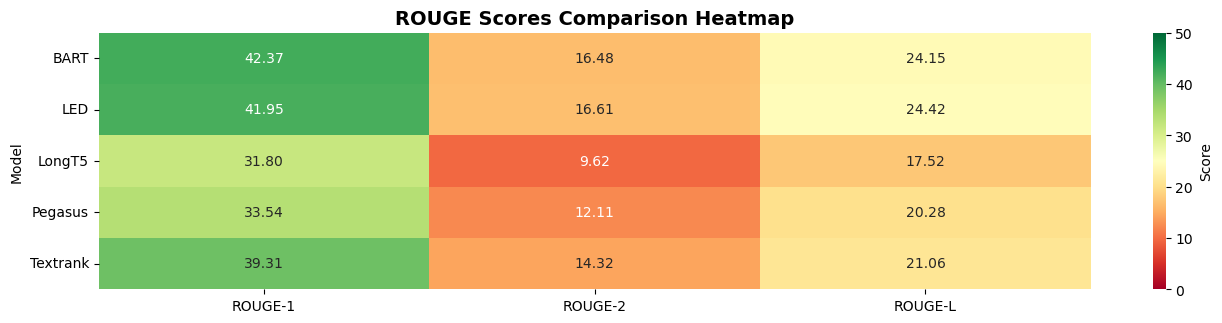

In [27]:
# ========== 3. VISUALIZATION ==========
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 3.1 HEATMAP - ROUGE Scores
ax1 = fig.add_subplot(gs[0, :])
rouge_cols = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
heatmap_data = comparison_df.set_index('Model')[rouge_cols]

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', 
            cbar_kws={'label': 'Score'}, ax=ax1, vmin=0, vmax=50)
ax1.set_title('ROUGE Scores Comparison Heatmap', fontsize=14, fontweight='bold')

In [28]:
# 3.2 BAR CHART - ROUGE Metrics
ax2 = fig.add_subplot(gs[1, 0])
x = np.arange(len(comparison_df))
width = 0.25

for i, col in enumerate(rouge_cols):
    ax2.bar(x + i*width, comparison_df[col], width, label=col)

ax2.set_xlabel('Model', fontweight='bold')
ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('ROUGE Scores by Model', fontsize=12, fontweight='bold')
ax2.set_xticks(x + width)
ax2.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

In [29]:
# 3.3 BOX PLOT - Distribution across ROUGE metrics
ax3 = fig.add_subplot(gs[1, 1])
box_data = [comparison_df[col].values for col in rouge_cols]
ax3.boxplot(box_data, labels=rouge_cols)
ax3.set_ylabel('Score', fontweight='bold')
ax3.set_title('ROUGE Metrics Distribution', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

In [30]:
# 3.4 Ranking - Best per metric
ax4 = fig.add_subplot(gs[2, 0])
best_rouge1_idx = comparison_df['ROUGE-1'].idxmax()
best_rouge2_idx = comparison_df['ROUGE-2'].idxmax()
best_rougel_idx = comparison_df['ROUGE-L'].idxmax()

ranking_data = {
    'ROUGE-1': comparison_df.loc[best_rouge1_idx, 'Model'],
    'ROUGE-2': comparison_df.loc[best_rouge2_idx, 'Model'],
    'ROUGE-L': comparison_df.loc[best_rougel_idx, 'Model']
}

colors = ['gold', 'silver', 'chocolate']
y_pos = np.arange(len(ranking_data))
scores = [
    comparison_df.loc[best_rouge1_idx, 'ROUGE-1'],
    comparison_df.loc[best_rouge2_idx, 'ROUGE-2'],
    comparison_df.loc[best_rougel_idx, 'ROUGE-L']
]

bars = ax4.barh(y_pos, scores, color=colors)
ax4.set_yticks(y_pos)
ax4.set_yticklabels(ranking_data.keys())
ax4.set_xlabel('Score', fontweight='bold')
ax4.set_title('Best Model per ROUGE Metric 🏆', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, model_name) in enumerate(zip(bars, ranking_data.values())):
    ax4.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
             f'{model_name} ({scores[i]:.2f})', 
             ha='left', va='center', fontweight='bold')

# 3.5 Model Info Table
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('off')

info_cols = ['Model', 'Tipe', 'Max Input Tokens', 'Test Samples']
table_data = comparison_df[info_cols].values
table = ax5.table(cellText=table_data, 
                  colLabels=info_cols,
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)


In [31]:
# ========== 4. EXPORT SUMMARY ==========
comparison_df.to_csv('metrics_comparison_summary.csv', index=False)
print("\n✓ Summary exported to: metrics_comparison_summary.csv")
print("✓ Visualization saved to: Master_Comparison_Analysis.png")


✓ Summary exported to: metrics_comparison_summary.csv
✓ Visualization saved to: Master_Comparison_Analysis.png


In [32]:
import os

models = ['BART', 'LED', 'LongT5', 'Pegasus', 'Textrank']

print("PNG FILES PER MODEL:\n")
for model in models:
    model_dir = f'../../Result/{model}'
    print(f"{model}:")
    
    try:
        files = os.listdir(model_dir)
        png_files = [f for f in files if f.endswith('.png')]
        for png in sorted(png_files):
            print(f"  - {png}")
    except FileNotFoundError:
        print(f"  ❌ Folder tidak ditemukan!")
    
    print()

PNG FILES PER MODEL:

BART:
  - viz_length_analysis.png
  - viz_rouge_bar_hist.png
  - viz_rouge_boxplot.png
  - viz_training_curves.png

LED:
  - viz_length_analysis.png
  - viz_rouge_bar_hist.png
  - viz_rouge_boxplot.png
  - viz_training_curves.png

LongT5:
  - viz_length_analysis.png
  - viz_rouge_bar_hist.png
  - viz_rouge_boxplot.png
  - viz_training_curves.png

Pegasus:
  - viz_length_analysis.png
  - viz_rouge_bar_hist.png
  - viz_rouge_boxplot.png
  - viz_training_curves.png

Textrank:
  - viz_length_analysis.png
  - viz_rouge_bar_hist.png
  - viz_rouge_boxplot.png



⚠️  Textrank: viz_training_curves.png tidak ditemukan

✓ Found 4 models dengan viz_training_curves.png

✓ Saved: All_Models_Training_Curves_Comparison.png


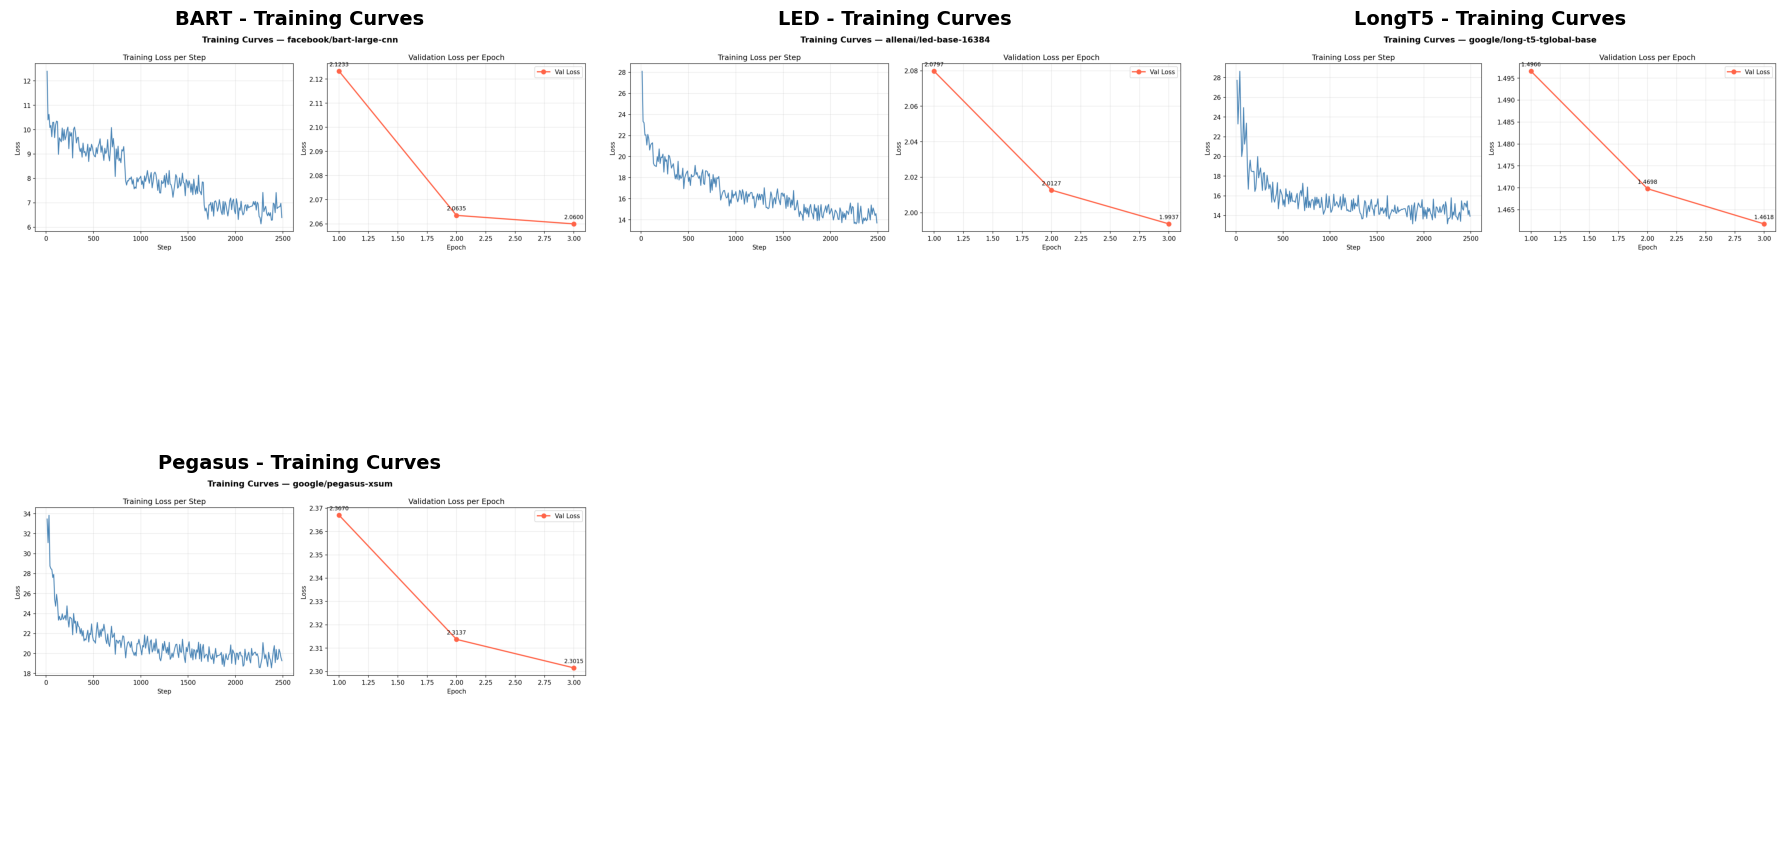

In [33]:
# ========== LOAD SEMUA PNG TRAINING CURVES & COMBINE ==========
from PIL import Image
import os

models = ['BART', 'LED', 'LongT5', 'Pegasus', 'Textrank']
png_file = 'viz_training_curves.png'

# Filter hanya model yang punya file
available_models = []
for model in models:
    png_path = f'../../Result/{model}/{png_file}'
    if os.path.exists(png_path):
        available_models.append((model, png_path))
    else:
        print(f"⚠️  {model}: {png_file} tidak ditemukan")

print(f"\n✓ Found {len(available_models)} models dengan {png_file}\n")

# Create figure grid
n_cols = 3
n_rows = (len(available_models) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()  # Flatten untuk indexing yang mudah

# Load dan display
for idx, (model_name, png_path) in enumerate(available_models):
    img = Image.open(png_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f'{model_name} - Training Curves', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(len(available_models), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('All_Models_Training_Curves_Comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: All_Models_Training_Curves_Comparison.png")
plt.show()

✓ Found 4 models

✓ Saved: 01_Training_Curves_Comparison.png


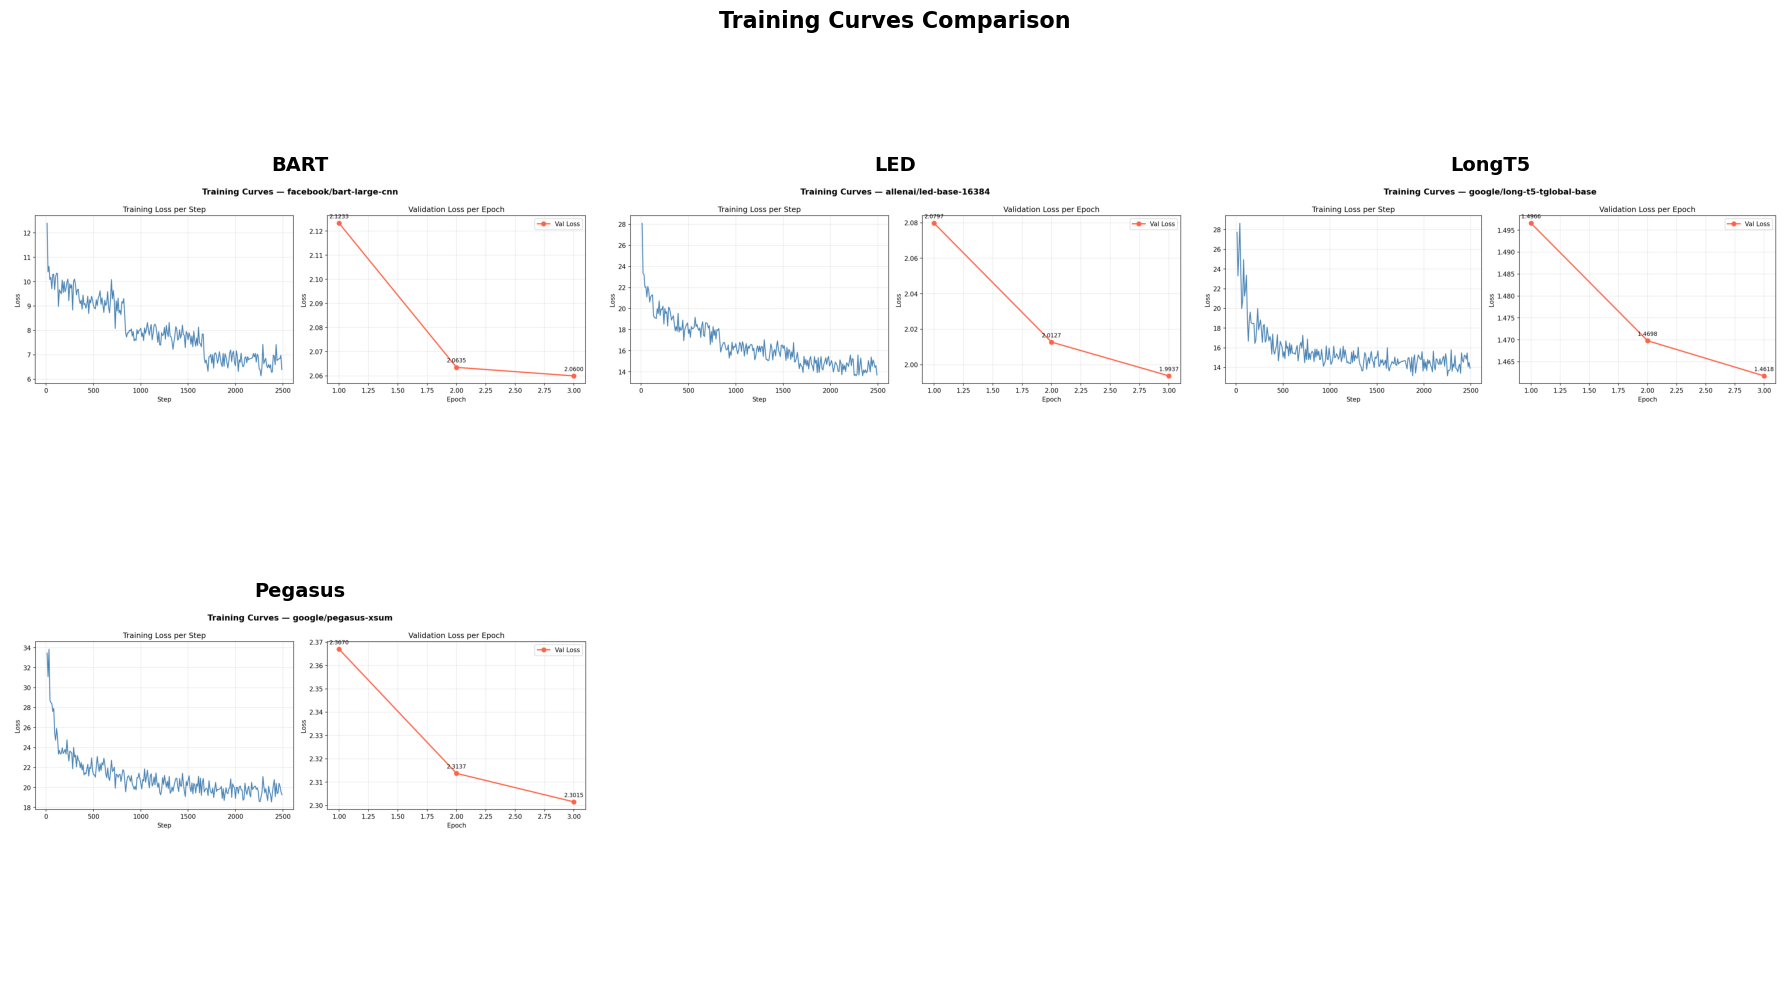

In [34]:
# ========== CELL 1: TRAINING CURVES COMPARISON ==========
from PIL import Image
import os
import matplotlib.pyplot as plt

models = ['BART', 'LED', 'LongT5', 'Pegasus', 'Textrank']
png_file = 'viz_training_curves.png'

# Filter model yang punya file
available_models = []
for model in models:
    png_path = f'../../Result/{model}/{png_file}'
    if os.path.exists(png_path):
        available_models.append((model, png_path))

print(f"✓ Found {len(available_models)} models\n")

# Create grid
n_cols = 3
n_rows = (len(available_models) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

# Load & display
for idx, (model_name, png_path) in enumerate(available_models):
    img = Image.open(png_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f'{model_name}', fontsize=14, fontweight='bold', pad=10)
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(len(available_models), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Training Curves Comparison', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../../Result/01_Training_Curves_Comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 01_Training_Curves_Comparison.png")
plt.show()

✓ Found 5 models

✓ Saved: 02_ROUGE_Bar_Hist_Comparison.png


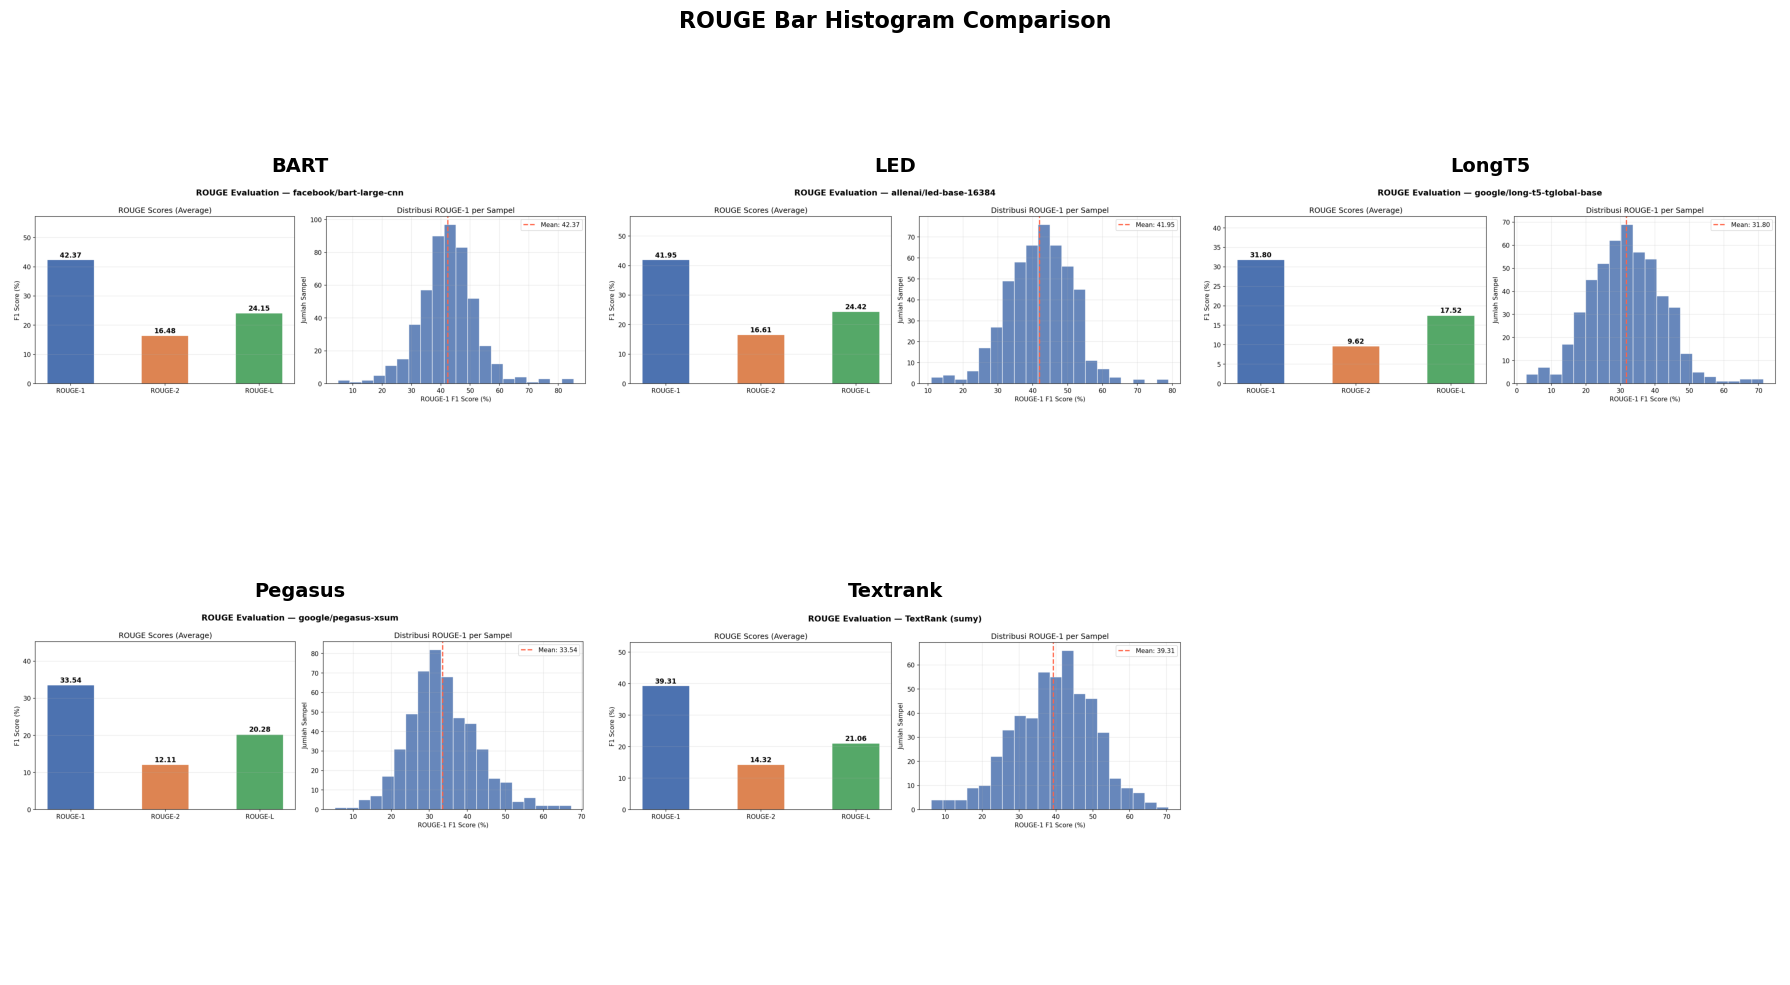

In [35]:
# ========== CELL 2: ROUGE BAR HISTOGRAM COMPARISON ==========
from PIL import Image
import os
import matplotlib.pyplot as plt

models = ['BART', 'LED', 'LongT5', 'Pegasus', 'Textrank']
png_file = 'viz_rouge_bar_hist.png'

# Filter model yang punya file
available_models = []
for model in models:
    png_path = f'../../Result/{model}/{png_file}'
    if os.path.exists(png_path):
        available_models.append((model, png_path))

print(f"✓ Found {len(available_models)} models\n")

# Create grid
n_cols = 3
n_rows = (len(available_models) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

# Load & display
for idx, (model_name, png_path) in enumerate(available_models):
    img = Image.open(png_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f'{model_name}', fontsize=14, fontweight='bold', pad=10)
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(len(available_models), len(axes)):
    axes[idx].axis('off')

plt.suptitle('ROUGE Bar Histogram Comparison', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../../Result/02_ROUGE_Bar_Hist_Comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 02_ROUGE_Bar_Hist_Comparison.png")
plt.show()

✓ Found 5 models

✓ Saved: 03_ROUGE_Boxplot_Comparison.png


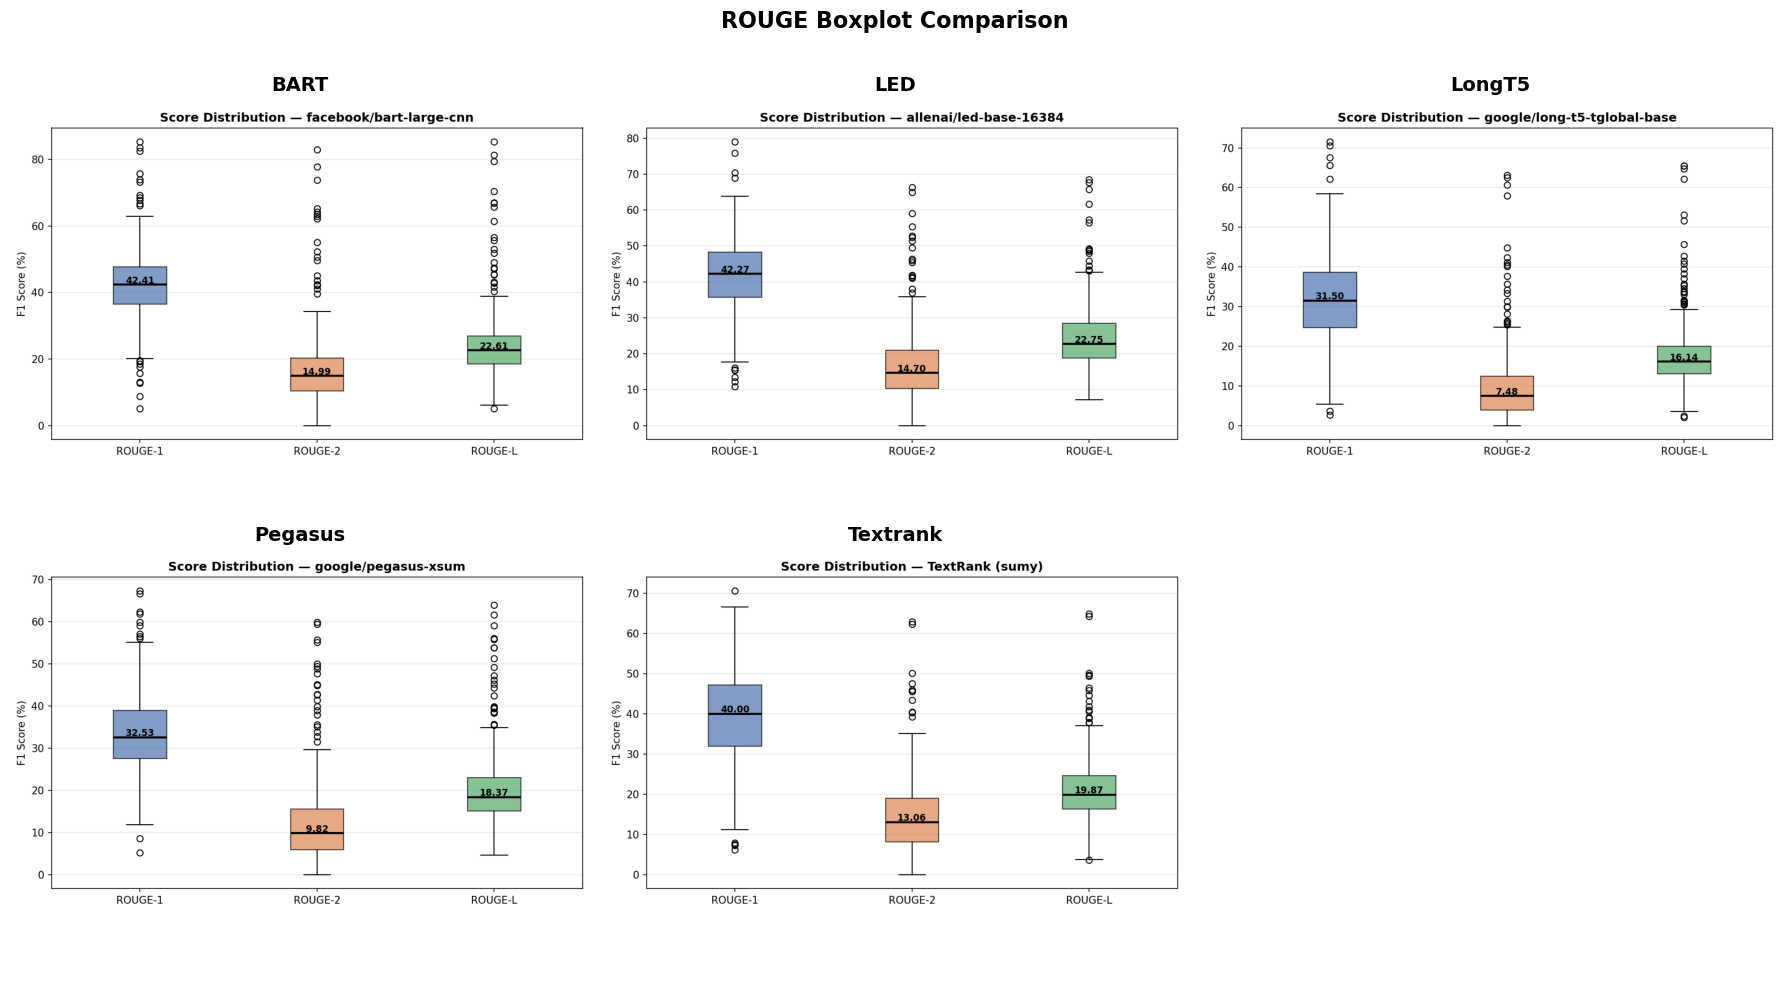

In [36]:
# ========== CELL 3: ROUGE BOXPLOT COMPARISON ==========
from PIL import Image
import os
import matplotlib.pyplot as plt

models = ['BART', 'LED', 'LongT5', 'Pegasus', 'Textrank']
png_file = 'viz_rouge_boxplot.png'

# Filter model yang punya file
available_models = []
for model in models:
    png_path = f'../../Result/{model}/{png_file}'
    if os.path.exists(png_path):
        available_models.append((model, png_path))

print(f"✓ Found {len(available_models)} models\n")

# Create grid
n_cols = 3
n_rows = (len(available_models) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

# Load & display
for idx, (model_name, png_path) in enumerate(available_models):
    img = Image.open(png_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f'{model_name}', fontsize=14, fontweight='bold', pad=10)
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(len(available_models), len(axes)):
    axes[idx].axis('off')

plt.suptitle('ROUGE Boxplot Comparison', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../../Result/03_ROUGE_Boxplot_Comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 03_ROUGE_Boxplot_Comparison.png")
plt.show()

✓ Found 5 models

✓ Saved: 04_Length_Analysis_Comparison.png


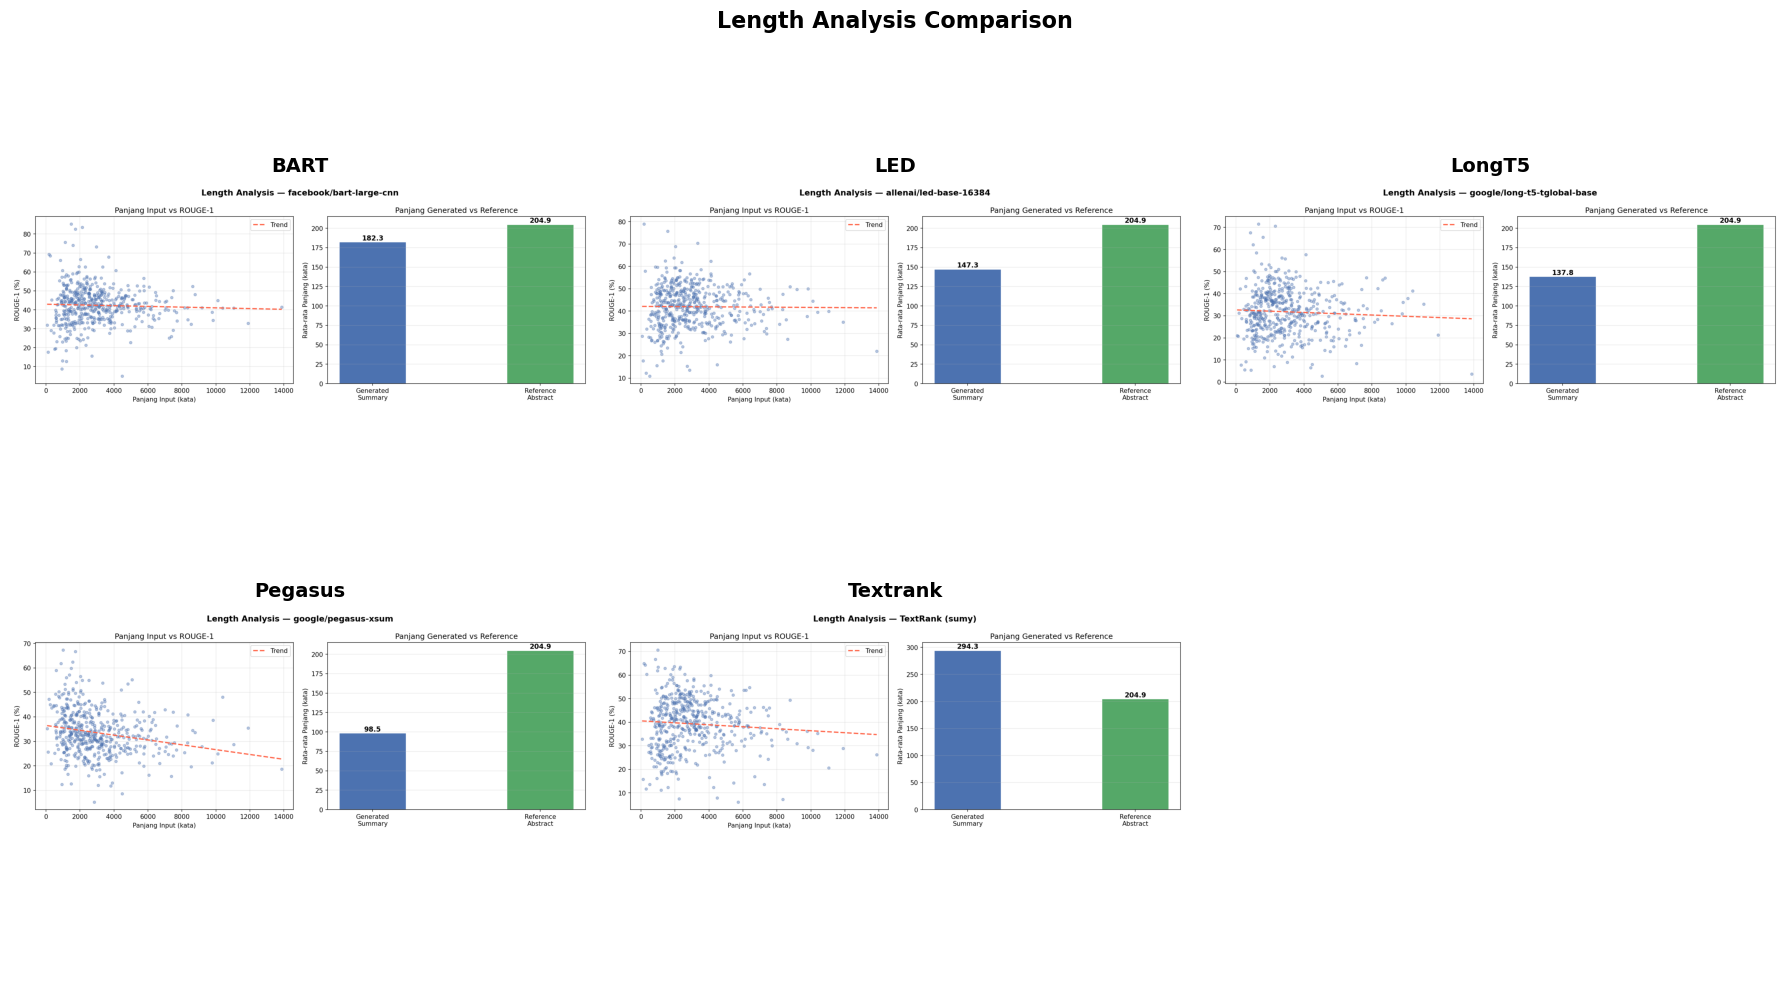

In [37]:
# ========== CELL 4: LENGTH ANALYSIS COMPARISON ==========
from PIL import Image
import os
import matplotlib.pyplot as plt

models = ['BART', 'LED', 'LongT5', 'Pegasus', 'Textrank']
png_file = 'viz_length_analysis.png'

# Filter model yang punya file
available_models = []
for model in models:
    png_path = f'../../Result/{model}/{png_file}'
    if os.path.exists(png_path):
        available_models.append((model, png_path))

print(f"✓ Found {len(available_models)} models\n")

# Create grid
n_cols = 3
n_rows = (len(available_models) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

# Load & display
for idx, (model_name, png_path) in enumerate(available_models):
    img = Image.open(png_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f'{model_name}', fontsize=14, fontweight='bold', pad=10)
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(len(available_models), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Length Analysis Comparison', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../../Result/04_Length_Analysis_Comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 04_Length_Analysis_Comparison.png")
plt.show()

---
## 💾 Simpan Semua Hasil ke Result/All Models

In [38]:
import os, shutil, glob

# ── Simpan semua output Comparative Analysis ke Result/All Models ──
OUTPUT_DIR = '../../Result/All Models'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Pindahkan semua PNG hasil comparison
comparison_pngs = glob.glob('./*Comparison*.png') + glob.glob('./All_Models*.png') + glob.glob('../../Result/0*_Comparison.png')
for f in comparison_pngs:
    dest = os.path.join(OUTPUT_DIR, os.path.basename(f))
    shutil.copy(f, dest)
    print(f'  ✅ {os.path.basename(f)} → Result/All Models')

# Pindahkan summary CSV
if os.path.exists('metrics_comparison_summary.csv'):
    shutil.copy('metrics_comparison_summary.csv', OUTPUT_DIR)
    print(f'  ✅ metrics_comparison_summary.csv → Result/All Models')

print(f'\n✅ Semua hasil comparative analysis disimpan ke: {OUTPUT_DIR}')


  ✅ All_Models_Training_Curves_Comparison.png → Result/All Models
  ✅ All_Models_Training_Curves_Comparison.png → Result/All Models
  ✅ 01_Training_Curves_Comparison.png → Result/All Models
  ✅ 02_ROUGE_Bar_Hist_Comparison.png → Result/All Models
  ✅ 03_ROUGE_Boxplot_Comparison.png → Result/All Models
  ✅ 04_Length_Analysis_Comparison.png → Result/All Models
  ✅ metrics_comparison_summary.csv → Result/All Models

✅ Semua hasil comparative analysis disimpan ke: ../../Result/All Models
